In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
class mandelbrot:
  '''
  A class of Mandelbrot sets.
  dependencies:
    import numpy as np
  '''
  def __init__(self, height=500,width=500,zoom=0.8,centerx=-0.6,centery=0,d=2):
    self.width = width
    self.height = height
    self.zoom = zoom # radius of pictures is 1/zoom
    self.centerx = centerx
    self.centery = centery
    self.cart_coords = np.zeros([height,width],dtype=complex) # the complex numbers associated with each pixel
    self.main_cardioid = np.zeros([height,width]) # one if in main cardioid, zero otherwise
    self.per2_disk = np.zeros([height,width]) # one if in period 2 disk, zero otherwise
    self.d = d # the exponent for the z**d+c
    for x in range(width):
      for y in range(height):
        cy = (1-2.*y/height+centery)/zoom
        cx = (2.*x/width-1+centerx)/zoom
        c = complex(cx,cy)
        self.cart_coords[y,x]=c
        if self.d==2:
          if np.abs(1-np.sqrt(1-4*c)) <= 1:
            self.main_cardioid[y,x] = 1
          if np.abs(c+1) < 1./4:
            self.per2_disk[y,x]=1
        else:
          coeff = np.zeros([d+1],dtype=complex)
          coeff[0]=1
          coeff[-2]=-1
          coeff[-1]=c
          for root in np.roots(coeff):
            if d*np.abs(root)**(d-1) < 1:
              self.main_cardioid[y,x]=1
              break
    self.mandelbrot_set = np.zeros([width,height]) # numpy array of pixels showing the Mandelbrot set
    self.portrait = np.zeros([width,height,3]) # numpy array of pixels showing something more customizable than mandelbrot_set
    self.equilibrium_measure = np.zeros([height,width]) # numpy array of pixels showing equilibrium measure on Mandelbrot set

  def make_mandelbrot(self,maxIter=100):
    self.mandelbrot_set = np.zeros([self.height,self.width])
    d = self.d
    for x in range(self.width):
      for y in range(self.height):
        # if in main cardioid or per2_disk, leave value as zero
        # otherwise iterate
        if self.main_cardioid[y,x]==0 and self.per2_disk[y,x]==0:
          # convert pixel to Cartesian coordinates
          c = self.cart_coords[y,x]
          z = self.cart_coords[y,x]
          i = maxIter
          # iterate (no need to start at 0 when the second value is c)
          while (z.real)**2 + (z.imag)**2 < 4 and i > 1:
            z = z**d + c
            i -= 1

          self.mandelbrot_set[y,x] = (i-1.0)/maxIter

  def plot_point(self,z,size=20,zoom=None):
    '''plot point z = complex(x,y) on portrait
    radius of point = sqrt(size)'''
    if np.max(self.portrait)==0:
      if np.max(self.mandelbrot_set)==0:
        self.make_mandelbrot()
      self.portrait = np.stack([mand.mandelbrot_set,mand.mandelbrot_set,mand.mandelbrot_set],axis=2)
    if zoom==None:
      zoom = self.zoom
    x = int((self.width/2)*(zoom*z.real+1-self.centerx))
    y = int((self.height/2)*(self.centery+1-zoom*z.imag))

    clip = int(np.sqrt(size)+1)
    for j in range(y-clip,y+clip+1):
      for k in range(x-clip,x+clip+1):
        if (j-y)**2 + (k-x)**2 < size:
          self.portrait[j,k,0]=1
          self.portrait[j,k,1]=0
          self.portrait[j,k,2]=0


  def plot_points(self,points,size=20,zoom=None):
    '''plot points of the form complex(x,y) from the list points'''
    for point in points:
      self.plot_point(point,size,zoom)

  def erase(self):
    '''
    reset the portrait to the mandelbrot set
    '''
    if np.max(self.mandelbrot_set)==0:
      self.make_mandelbrot()
    self.portrait = np.stack([mand.mandelbrot_set,mand.mandelbrot_set,mand.mandelbrot_set],axis=2)

  def make_equilibrium_measure(self,iterations=100,delta=0.1,thresh=0.7):
    '''
    get the equilibrium measure of the Mandelbrot set by using a Monte Carlo method
    based on the Brownian motion interpretation of equilibrium measure
    assumes the entire Mandelbrot set can be seen in self.mandelbrot_set
    also assumes self.height==self.width
    '''
    w = self.width
    h = self.height
    cx = self.centerx
    cy = self.centery
    zoom = self.zoom
    # get an array that shows the disk of radius 2 and matches up with self.mandelbrot_set
    H = int(h*zoom)
    W = int(w*zoom)
    x_shift = int((W/2.)*(2.+(cx-1.)/zoom))
    y_shift = int((H/2.)*(2.+(cy-1.)/zoom))
    disk = np.zeros([2*H,2*W])
    for x in range(2*W):
      for y in range(2*H):
        # this is where we assume self.height==self.width to avoid extra computation
        if (x-W)**2+(y-H)**2 <=  W**2:
          disk[y,x]=1

    # a function to check if [i,j] is not in the Mandelbrot set.  Assumes not if not in frame
    def off_set(i,j):
      try:
        return self.mandelbrot_set[i,j]>thresh # if the value is small enough, assume it's on the Mandelbrot set
      except:
        return True

    # a function to check if [i,j] is in the disk of radius 2.  Assumes not if not in frame
    def on_disk(i,j):
      try:
        return disk[i+y_shift,j+x_shift]
      except:
        return False
    # Brownian motion starting at infinity is equally likely to first hit anywhere
    # on the circle of radius 2 centered at 0.  It continues from there until it
    # hits the Mandelbrot set
    for k in range(iterations):
      # get a point zeta on the circle of radius 2 centered at 0
      theta = np.random.uniform(0,2*np.pi)
      zeta = 2*np.exp(theta*1j)
      # convert zeta to pixel coordinates in self.mandelbrot_set
      x = int((w/2)*(zoom*zeta.real+1-cx))
      y = int((h/2)*(cy+1-zoom*zeta.imag))


      # perform the random walk
      # stop if we're on the Mandelbrot set
      while off_set(y,x):
        move = np.random.choice(4)
        neighbors = [(x-1,y),(x+1,y),(x,y-1),(x,y+1)]
        a,b = neighbors[move]
        # if we're not moving outside the circle, move.  Otherwise, stay put
        if on_disk(b,a):
          x,y = a,b
      # [x,y] is on the Mandelbrot set
      self.equilibrium_measure[y,x]+=1

In [ ]:
mand = mandelbrot(height=500,width=500,d=3,centerx=0,centery=0,zoom=0.8)

In [ ]:
mand.make_mandelbrot()

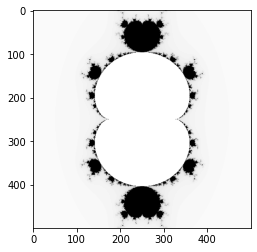

In [ ]:
plt.imshow(mand.mandelbrot_set+mand.main_cardioid,cmap='gray')

In [ ]:
mand.erase()
mand.plot_points([0+0j,1+0j,0+1j,0.4+0.5j])

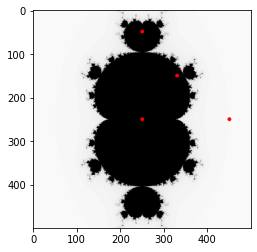

In [ ]:
plt.imshow(mand.portrait)

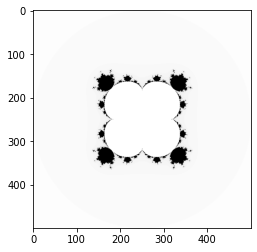

In [ ]:
plt.imshow(mand.mandelbrot_set+mand.main_cardioid,cmap='gray')

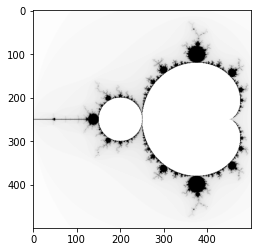

In [ ]:
splt.imshow(mand.mandelbrot_set+mand.main_cardioid + mand.per2_disk,cmap='gray')

In [ ]:
plt.imsave('main-cardioid.png',mand.mandelbrot_set+mand.main_cardioid,cmap='gray')

In [ ]:
mand.erase()
pts = [-0.12+0.75j]
mand.plot_points(pts)

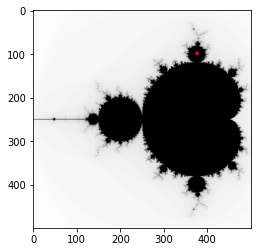

In [ ]:
plt.imshow(mand.portrait)

In [ ]:
cx,cy = np.meshgrid(np.arange(-0.6,0.4,0.2),np.arange(-0.4,0.6,0.2))
c_array = cx + cy*1j

In [ ]:
c_array = np.array([[0+0.2j,0.2+0.2j],[0+0j,0.2+0j]])

In [ ]:
mand.erase()

In [ ]:
mand.portrait+=+np.stack([mand.main_cardioid,mand.main_cardioid,mand.main_cardioid],axis=2)

In [ ]:
mand.plot_points(c_array.flatten(),size=30)

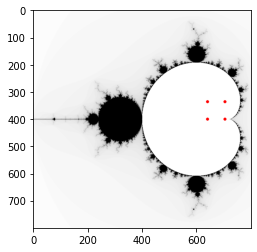

In [ ]:
plt.imshow(mand.portrait)

In [ ]:
plt.imsave('mand-quas.png',mand.portrait)

In [ ]:
mand.erase()

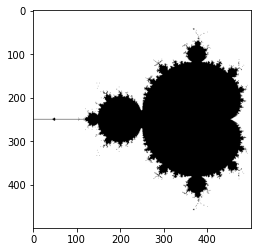

In [ ]:
plt.imshow(mand.mandelbrot_set>0.7,cmap='gray')